In [206]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import talib.abstract as ta
import scipy as sp
from sklearn.preprocessing import PowerTransformer
from typing import List

# Import Data

In [207]:
# Apple Futures data using yfinance
ticker = 'AAPL'
data = yf.download(ticker, start="2015-01-01", interval="1D")

# Check the data
display(data.head())

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2015-01-02,24.214891,24.682224,23.776352,24.671149,212818400
2015-01-05,23.532719,24.064282,23.346673,23.984547,257142000
2015-01-06,23.534943,23.794079,23.173922,23.596958,263188400
2015-01-07,23.864950,23.964618,23.632391,23.743133,160423600
2015-01-08,24.781893,24.839479,24.075357,24.192745,237458000


In [208]:
data.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 2806 entries, 2015-01-02 to 2026-03-02
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, AAPL)   2806 non-null   float64
 1   (High, AAPL)    2806 non-null   float64
 2   (Low, AAPL)     2806 non-null   float64
 3   (Open, AAPL)    2806 non-null   float64
 4   (Volume, AAPL)  2806 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 131.5 KB


In [209]:
data.columns = ['Close','High','Low','Open','Volume']

In [210]:
data_copy = data.copy()

In [211]:
from statsforecast import StatsForecast
from statsforecast.models import AutoARIMA

In [212]:
data.reset_index(drop=False, inplace=True)

In [213]:
data.columns

Index(['Date', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='str')

In [214]:
df = data[['Date','Close']].copy()
df.columns = ['ds','y']
df['unique_id'] = 'AAPL'

In [215]:
df['y'] = df['y'].diff()
df.dropna(inplace=True)

In [216]:
df.head()

,ds,y,unique_id
1,2015-01-05,-0.682173,AAPL
2,2015-01-06,0.002224,AAPL
3,2015-01-07,0.330008,AAPL
4,2015-01-08,0.916943,AAPL
5,2015-01-09,0.026581,AAPL


In [217]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2805 entries, 1 to 2805
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype        
---  ------     --------------  -----        
 0   ds         2805 non-null   datetime64[s]
 1   y          2805 non-null   float64      
 2   unique_id  2805 non-null   str          
dtypes: datetime64[s](1), float64(1), str(1)
memory usage: 65.9 KB


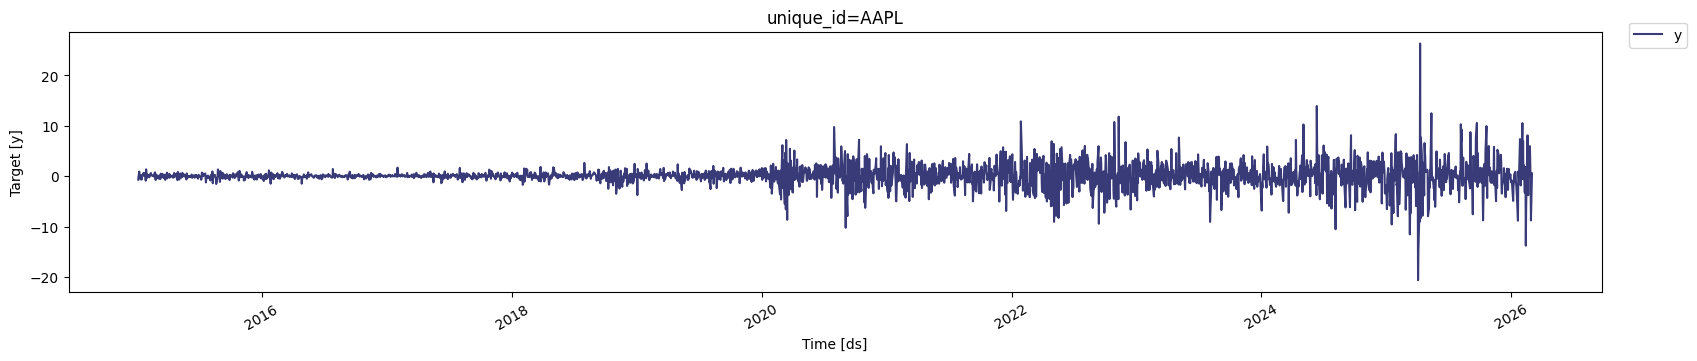

In [218]:
StatsForecast.plot(df)

In [219]:
#df['y'] = df['y'].diff()
df.dropna(inplace=True)

In [220]:
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.tsaplots import plot_pacf

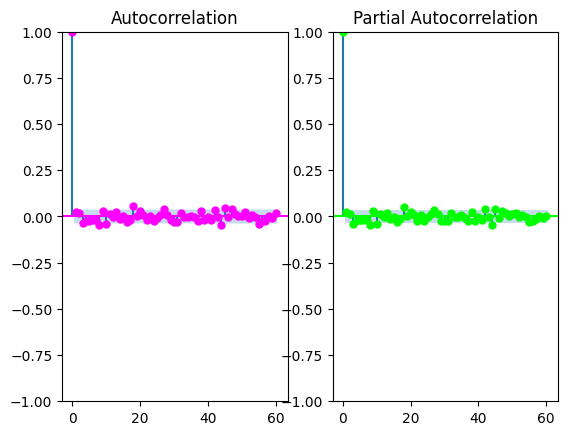

In [221]:
fig, axs = plt.subplots(nrows=1, ncols=2)

plot_acf(df["y"],  lags=60, ax=axs[0],color="fuchsia")
axs[0].set_title("Autocorrelation");

plot_pacf(df["y"],  lags=60, ax=axs[1],color="lime")
axs[1].set_title('Partial Autocorrelation')

plt.show();

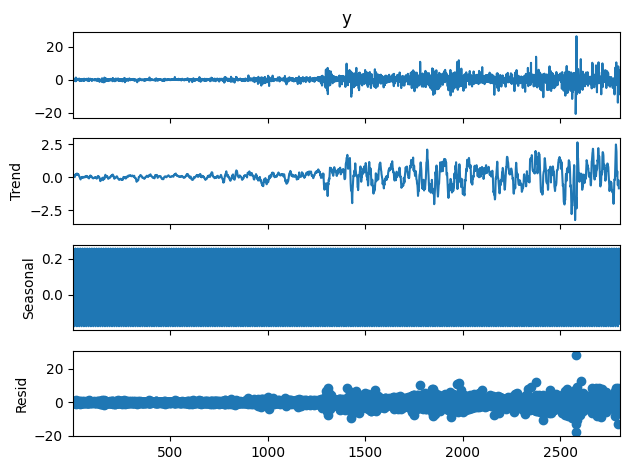

In [222]:
from statsmodels.tsa.seasonal import seasonal_decompose
a = seasonal_decompose(df["y"], model = "add", period=12)
a.plot();

In [223]:
from statsmodels.tsa.stattools import adfuller

In [224]:
def check_stationarity(timeseries):
    result = adfuller(timeseries)
    print(f'ADF İstatistiği: {result[0]}')
    print(f'p-değeri: {result[1]}')
    return result[1] <= 0.05

In [225]:
check_stationarity(df['y'])

ADF İstatistiği: -18.44252686133691
p-değeri: 2.159976090672486e-30


np.True_

In [226]:
Y_train_df = df[df.ds<='2026-01-01']
Y_test_df = df[df.ds>'2026-01-01']

In [227]:
import seaborn as sns

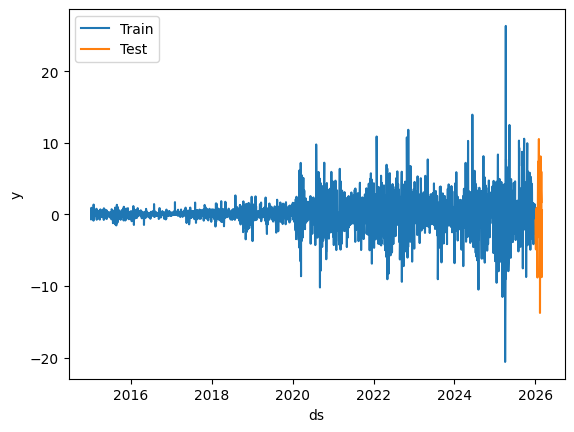

In [228]:
sns.lineplot(Y_train_df,x="ds", y="y", label="Train")
sns.lineplot(Y_test_df, x="ds", y="y", label="Test")
plt.show()

In [229]:
models = [AutoARIMA(season_length=5)] # Aylık veri için 12 aylık mevsimsellik

In [230]:
sf = StatsForecast(
    models=models, 
    freq='D', 
    n_jobs=-1 
)

In [231]:
sf.fit(df=Y_train_df)

StatsForecast(models=[AutoARIMA])

In [232]:
result=sf.fitted_[0,0].model_
print(result.keys())
print(result['arma'])

dict_keys(['coef', 'sigma2', 'var_coef', 'mask', 'loglik', 'aic', 'arma', 'residuals', 'code', 'n_cond', 'nobs', 'model', 'bic', 'aicc', 'ic', 'xreg', 'x', 'lambda'])
(3, 1, 2, 0, 5, 0, 0)


In [233]:
residual=pd.DataFrame(result.get("residuals"), columns=["residual Model"])
residual

,residual Model
0,-0.769197
1,-0.070937
2,0.254612
3,0.787561
4,-0.111256
...,...
2760,1.437232
2761,-0.743969
2762,0.204477
2763,-0.915749


In [234]:
import scipy.stats as stats

/tmp/ipykernel_91887/3728362320.py:4: Pandas4Warning: The copy keyword is deprecated and will be removed in a future version. Copy-on-Write is active in pandas since 3.0 which utilizes a lazy copy mechanism that defers copies until necessary. Use .copy() to make an eager copy if necessary.
  residual.plot(ax=axs[0,0])
/tmp/ipykernel_91887/3728362320.py:8: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(residual, ax=axs[0,1]);


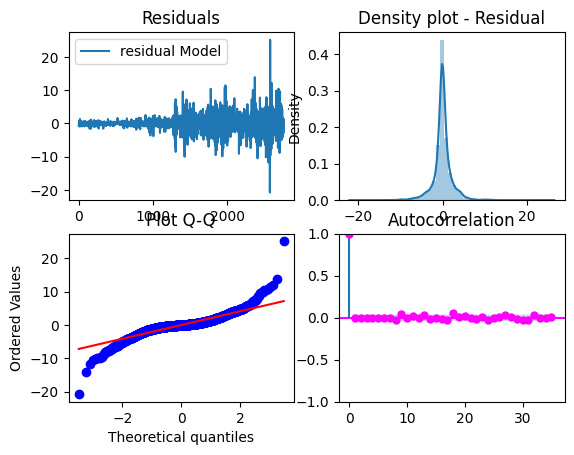

In [ ]:
fig, axs = plt.subplots(nrows=2, ncols=2)

# plot[1,1]
residual.plot(ax=axs[0,0])
axs[0,0].set_title("Residuals")

# plot
sns.distplot(residual, ax=axs[0,1])
axs[0,1].set_title("Density plot - Residual")

# plot
stats.probplot(residual["residual Model"], dist="norm", plot=axs[1,0])
axs[1,0].set_title('Plot Q-Q')

# plot
plot_acf(residual,  lags=35, ax=axs[1,1],color="fuchsia")
axs[1,1].set_title("Autocorrelation")

plt.show();

In [236]:
Y_hat_df = sf.forecast(df=Y_train_df, h=len(Y_test_df), fitted=True)
Y_hat_df.head()

,unique_id,ds,AutoARIMA
0,AAPL,2026-01-01,0.184927
1,AAPL,2026-01-02,0.086628
2,AAPL,2026-01-03,0.108384
3,AAPL,2026-01-04,0.279237
4,AAPL,2026-01-05,0.061299


In [237]:
plot_df = Y_test_df.merge(Y_hat_df, how='left')

In [238]:
plot_df

,ds,y,unique_id,AutoARIMA
0,2026-01-02,-0.849182,AAPL,0.086628
1,2026-01-05,-3.746490,AAPL,0.061299
2,2026-01-06,-4.895447,AAPL,0.051492
3,2026-01-07,-2.028107,AAPL,0.128654
4,2026-01-08,-1.288757,AAPL,0.085203
5,2026-01-09,0.329681,AAPL,0.132282
6,2026-01-12,0.879181,AAPL,0.090660
7,2026-01-13,0.799225,AAPL,0.088999
8,2026-01-14,-1.088959,AAPL,0.081018
9,2026-01-15,-1.748383,AAPL,0.091531


/tmp/ipykernel_91887/2643377784.py:2: Pandas4Warning: The copy keyword is deprecated and will be removed in a future version. Copy-on-Write is active in pandas since 3.0 which utilizes a lazy copy mechanism that defers copies until necessary. Use .copy() to make an eager copy if necessary.
  plot_df[['y', 'AutoARIMA']].plot(ax=ax, linewidth=2)


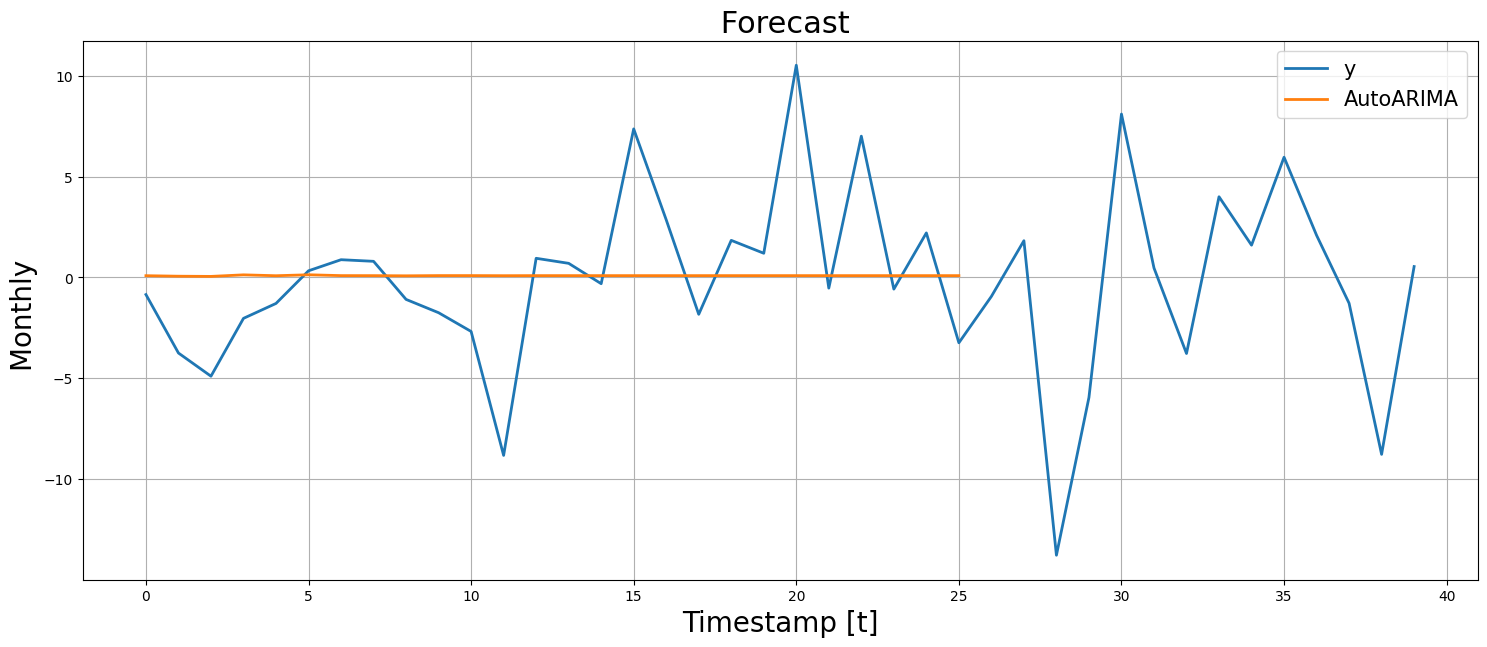

In [239]:

fig, ax = plt.subplots(1, 1, figsize = (18, 7))
plot_df[['y', 'AutoARIMA']].plot(ax=ax, linewidth=2)
ax.set_title(' Forecast', fontsize=22)
ax.set_ylabel('Monthly ', fontsize=20)
ax.set_xlabel('Timestamp [t]', fontsize=20)
ax.legend(prop={'size': 15})
ax.grid()